In [28]:
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
import torch
import torch.nn as nn
import matplotlib.patches as patches

from torch.utils.data import Dataset, DataLoader

device = "cuda"
torch.backends.cudnn.benchmark = True

In [29]:
# -----------------------
# 1. Generate diffusion data (Dirichlet BC)
# -----------------------
def diffusion_solver_dirichlet(u0, nu=0.01, dx=1/128, dt=1e-4, n_steps=2000):
    """Explicit finite-difference solver for 1D diffusion (Dirichlet BCs u(0,t)=u(1,t)=0)."""
    u = u0.copy()
    Nx = len(u)
    traj = [u.copy()]
    for _ in range(n_steps):
        un = u.copy()

        # discrete Laplacian on interior points only (no np.roll)
        lap = (un[2:] - 2*un[1:-1] + un[:-2]) / dx**2
        u[1:-1] = un[1:-1] + nu * dt * lap

        # Dirichlet boundaries
        u[0] = 0.0
        u[-1] = 0.0

        traj.append(u.copy())
    return np.stack(traj)  # shape (T, Nx)

def generate_diffusion_data(Nx=128, nu=0.01, dt=1e-4, n_steps=4000):
    dx = 1.0 / (Nx - 1)
    x = np.linspace(0, 1, Nx)

    # initial condition compatible with Dirichlet BC
    u0 = np.sin(2*np.pi * x)   # = 0 at x=0 and x=1

    data = diffusion_solver_dirichlet(u0, nu, dx, dt, n_steps)
    return x, data  # data[t, x]

# -----------------------
# 3. Training setup
# -----------------------
Nx =500
dt0 = 1e-4
nu = 0.01
n_steps = 20000

x, data = generate_diffusion_data(Nx, nu, dt0, n_steps)


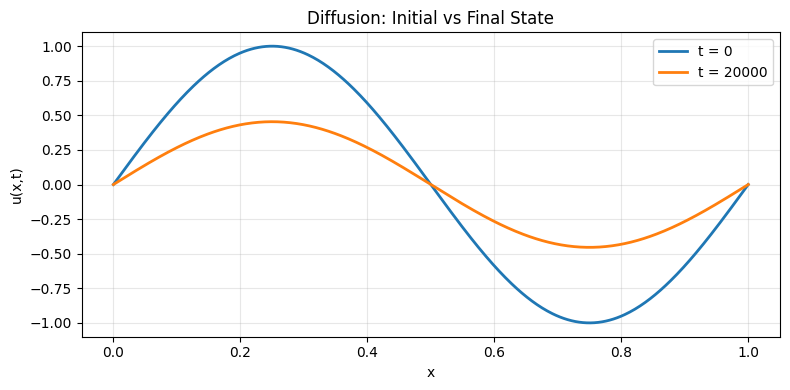

In [30]:
t_plot = n_steps  # or whatever final index you used

plt.figure(figsize=(8,4))
plt.plot(x, data[0], label="t = 0", linewidth=2)
plt.plot(x, data[t_plot], label=f"t = {t_plot}", linewidth=2)
plt.title("Diffusion: Initial vs Final State")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [31]:
def sample_one_B(u, R=5, k=5, max_tries=50, u_scale=None, rng=np.random):
    """
    Sample a single Scheme-B training example using an index-space square.

    Square geometry:
        t in [t0-R, t0+R], x in [x0-R, x0+R]

    Returns:
        feats_flat: (k*3,) with [dt_scaled, dx_scaled, u_scaled]
        target: scalar normalized u(t0,x0)
    """
    Nt, Nx = u.shape

    if u_scale is None:
        u_scale = np.max(np.abs(u)) + 1e-8

    for _ in range(max_tries):

        # ---- 1. sample random center ----
        t0 =  rng.randint(0, Nt)
        x0 =  rng.randint(0, Nx)

        # ---- 2. square bounds ----
        t_min = max(0, t0 - R)
        t_max = min(Nt - 1, t0 + R)
        x_min = max(0, x0 - R)
        x_max = min(Nx - 1, x0 + R)

        # ---- 3. collect candidates ----
        cand = []
        for t in range(t_min, t_max + 1):
            for x in range(x_min, x_max + 1):
                if t == t0 and x == x0:
                    continue
                cand.append((t, x))

        if len(cand) < k:
            continue

        # ---- 4. pick k random neighbors ----
        cand = np.array(cand)
        idx = np.random.choice(len(cand), size=k, replace=False)
        neigh = cand[idx]

        # ---- 5. build feature vector ----
        feats = []
        for (tn, xn) in neigh:
            dt_scaled = (t0 - tn)
            dx_scaled = (x0 - xn)
            u_scaled = u[tn, xn] / u_scale
            feats.append([dt_scaled, dx_scaled, u_scaled])

        feats = np.array(feats, dtype=np.float32).reshape(-1)
        target = np.float32(u[t0, x0] / u_scale)
        return feats, target

    raise RuntimeError("Failed to sample B-example; try changing R/k.")


In [32]:
class BDataset(Dataset):
    """
    Scheme-B dataset:
    - u: PDE solution, shape (Nt, Nx)
    - N_samples: number of samples
    """
    def __init__(self, u, N_samples=50000, R=5, k=5, seed=0, pregenerate=False):
        self.u = u
        self.N_samples = N_samples
        self.R = R
        self.k = k
        self.rng = np.random.RandomState(seed)

        # global normalization for u
        self.u_scale = np.max(np.abs(u)) + 1e-8

        self.pregenerate = pregenerate
        if pregenerate:
            print(f"Pre-generating {N_samples} samples...")
            feats = []
            targets = []

            for i in range(N_samples):
                if (i + 1) % 10000 == 0:
                    print(f"  Generated {i+1}/{N_samples}")

                f, t = sample_one_B(
                    self.u,
                    R=self.R,
                    k=self.k,
                    u_scale=self.u_scale,
                    rng=self.rng,
                )
                feats.append(f)
                targets.append(t)

            self.feats_tensor = torch.from_numpy(
                np.asarray(feats, dtype=np.float32)
            )
            self.targets_tensor = torch.from_numpy(
                np.asarray(targets, dtype=np.float32)
            )

            print("Pre-generation complete.")

    def __len__(self):
        return self.N_samples

    def __getitem__(self, idx):
        if self.pregenerate:
            return self.feats_tensor[idx], self.targets_tensor[idx]
        else:
            feats, target = sample_one_B(
                self.u,
                R=self.R,
                k=self.k,
                u_scale=self.u_scale,
                rng=self.rng,
            )
            return (
                torch.from_numpy(feats),
                torch.tensor(target, dtype=torch.float32),
            )


In [33]:
class LinearIntegrator(nn.Module):
    def __init__(self, k=5):
        super().__init__()
        self.lin = nn.Linear(k * 3, 1)

    def forward(self, x):
        return self.lin(x).squeeze(-1)


In [34]:
class MLPIntegrator(nn.Module):
    def __init__(self, k=5, hidden=128, num_layers=3):
        super().__init__()
        in_dim = k * 3
        layers = [nn.Linear(in_dim, hidden), nn.ReLU()]

        for _ in range(num_layers - 2):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]

        layers.append(nn.Linear(hidden, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


In [35]:
def train_integrator_B(
    model,
    u,
    epochs=50,
    batch_size=2048,
    k=5,
    R=5,
    N_samples=100000,
    lr=1e-3,
    pregenerate=True,
):
    """
    Minimal training loop for Scheme-B integrators.

    Args:
        model: torch.nn.Module (linear or MLP)
        u: numpy array (Nt, Nx)
    Returns:
        model: trained model
        train_losses: list of epoch-wise MSE
    """
    device = "cuda"
    model = model.to(device)

    dataset = BDataset(
        u,
        N_samples=N_samples,
        R=R,
        k=k,
        pregenerate=pregenerate,
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True,
    )

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    train_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for feats, target in loader:
            feats = feats.to(device)
            target = target.to(device)

            opt.zero_grad()
            pred = model(feats)
            loss = loss_fn(pred, target)
            loss.backward()
            opt.step()

            total_loss += loss.item() * feats.size(0)

        avg_loss = total_loss / len(dataset)
        train_losses.append(avg_loss)

        print(f"[Epoch {epoch+1}/{epochs}] train MSE = {avg_loss:.6e}")

    return model, train_losses


In [36]:
def eval_integrator_B(model, u, R, k, N_test=10000, batch_size=4096,):
    device = "cuda"
    model.eval()
    test_ds = BDataset( u, N_samples=N_test,R=R,k=k, seed=123,pregenerate=True,    )
    loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0,pin_memory=True,)
    loss_fn = nn.MSELoss()
    total_loss = 0.0
    with torch.no_grad():
        for feats, target in loader:
            feats = feats.to(device)
            target = target.to(device)
            pred = model(feats)
            loss = loss_fn(pred, target)
            total_loss += loss.item() * feats.size(0)
    avg_loss = total_loss / N_test
    print(f"[Eval] MSE = {avg_loss:.6e}")
    return avg_loss

In [37]:
def visualize_B_with_prediction(u, model, R=5, k=5):
    model.eval()
    device = "cuda"
    Nt, Nx = u.shape

    # ---- choose random center ----
    t0 = np.random.randint(0, Nt)
    x0 = np.random.randint(0, Nx)

    # ---- square neighborhood ----
    t_min = max(0, t0 - R)
    t_max = min(Nt - 1, t0 + R)
    x_min = max(0, x0 - R)
    x_max = min(Nx - 1, x0 + R)

    cand = []
    for t in range(t_min, t_max + 1):
        for x in range(x_min, x_max + 1):
            if t == t0 and x == x0:
                continue
            cand.append((t, x))

    cand = np.array(cand)
    if len(cand) < k:
        raise RuntimeError("Not enough neighbors found")

    # ---- pick k neighbors ----
    idx = np.random.choice(len(cand), size=k, replace=False)
    neigh = cand[idx]

    # ---- build features (exactly like sample_one_B) ----
    u_scale = np.max(np.abs(u)) + 1e-8
    feats = []
    for (tn, xn) in neigh:
        dt = t0 - tn
        dx = x0 - xn
        u_scaled = u[tn, xn] / u_scale
        feats.append([dt, dx, u_scaled])

    feats = np.array(feats, dtype=np.float32).reshape(1, -1)

    # ---- predict ----
    feats_torch = torch.from_numpy(feats).to(device)
    with torch.no_grad():
        pred = model(feats_torch).item() * u_scale

    true = u[t0, x0]

    # ---- plot ----
    fig, ax = plt.subplots(figsize=(5, 5))

    # square
    rect = plt.Rectangle(
        (x_min, t_min),
        x_max - x_min,
        t_max - t_min,
        fill=False,
        edgecolor="blue",
        linewidth=1.5,
    )
    ax.add_patch(rect)

    # neighbors
    ax.scatter(neigh[:, 1], neigh[:, 0], s=120, label="neighbors")
    for (tn, xn) in neigh:
        ax.plot([x0, xn], [t0, tn], alpha=0.6)

    # target
    ax.scatter([x0], [t0], c="red", s=200, label="target")

    pad = 2
    ax.set_xlim(x_min - pad, x_max + pad)
    ax.set_ylim(t_max + pad, t_min - pad)  # time upward

    ax.set_xlabel("x (space index)")
    ax.set_ylabel("t (time index, upward)")
    ax.set_title(
        f"u_true={true:.5f}, u_pred={pred:.5f}, "
        f"rel err={(true - pred) / true * 100:.3f}%"
    )

    ax.set_aspect("equal", adjustable="box")
    ax.legend()
    plt.tight_layout()
    plt.show()


In [38]:
def save_integrator_model(model, model_type, path, config):
    """
    Save a trained integrator model.

    Args:
        model: trained torch.nn.Module
        model_type: str ("linear" or "mlp")
        config: dict with required hyperparameters
    """
    torch.save(
        {
            "model_type": model_type,
            "model_state_dict": model.state_dict(),
            "config": config,
        },
        path,
    )


In [39]:
def load_integrator_model(path):
    """
    Load a saved integrator model.
    """
    device = "cuda"
    checkpoint = torch.load(path, map_location=device)

    model_type = checkpoint["model_type"]
    config = checkpoint["config"]

    if model_type == "linear":
        model = LinearIntegrator(k=config["k"])
    elif model_type == "mlp":
        model = SmallMLPIntegrator(
            k=config["k"],
            hidden=config["hidden"],
            num_layers=config["num_layers"],
        )
    else:
        raise ValueError(f"Unknown model type: {model_type}")

    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device)
    model.eval()

    return model, config


In [62]:
# =========================
# Experiments
# =========================

R = 5
k = 5
epochs = 100
batch_size = 2048
N_samples = 100000
lr = 1e-3

In [63]:
model_lin = LinearIntegrator(k=k)
model_lin, loss_lin = train_integrator_B(
    model_lin,
    data,
    epochs=epochs,
    batch_size=batch_size,
    k=k,
    R=R,
    N_samples=N_samples,
    lr=lr,
)


Pre-generating 100000 samples...
  Generated 10000/100000
  Generated 20000/100000
  Generated 30000/100000
  Generated 40000/100000
  Generated 50000/100000
  Generated 60000/100000
  Generated 70000/100000
  Generated 80000/100000
  Generated 90000/100000
  Generated 100000/100000
Pre-generation complete.
[Epoch 1/100] train MSE = 2.175590e+00
[Epoch 2/100] train MSE = 1.227187e+00
[Epoch 3/100] train MSE = 6.753854e-01
[Epoch 4/100] train MSE = 3.559780e-01
[Epoch 5/100] train MSE = 1.767512e-01
[Epoch 6/100] train MSE = 8.207450e-02
[Epoch 7/100] train MSE = 3.554594e-02
[Epoch 8/100] train MSE = 1.439007e-02
[Epoch 9/100] train MSE = 5.481299e-03
[Epoch 10/100] train MSE = 1.987218e-03
[Epoch 11/100] train MSE = 7.218071e-04
[Epoch 12/100] train MSE = 2.944211e-04
[Epoch 13/100] train MSE = 1.605409e-04
[Epoch 14/100] train MSE = 1.216754e-04
[Epoch 15/100] train MSE = 1.112091e-04
[Epoch 16/100] train MSE = 1.085949e-04
[Epoch 17/100] train MSE = 1.079734e-04
[Epoch 18/100] train

In [64]:
model_mlp =  MLPIntegrator(k=k, hidden=128, num_layers=3)
model_mlp, loss_mlp = train_integrator_B(
    model_mlp,
    data,
    epochs=epochs,
    batch_size=batch_size,
    k=k,
    R=R,
    N_samples=N_samples,
    lr=lr,
)


Pre-generating 100000 samples...
  Generated 10000/100000
  Generated 20000/100000
  Generated 30000/100000
  Generated 40000/100000
  Generated 50000/100000
  Generated 60000/100000
  Generated 70000/100000
  Generated 80000/100000
  Generated 90000/100000
  Generated 100000/100000
Pre-generation complete.
[Epoch 1/100] train MSE = 9.211589e-02
[Epoch 2/100] train MSE = 5.435046e-03
[Epoch 3/100] train MSE = 3.672494e-03
[Epoch 4/100] train MSE = 2.853202e-03
[Epoch 5/100] train MSE = 2.310197e-03
[Epoch 6/100] train MSE = 1.938372e-03
[Epoch 7/100] train MSE = 1.668002e-03
[Epoch 8/100] train MSE = 1.456918e-03
[Epoch 9/100] train MSE = 1.289704e-03
[Epoch 10/100] train MSE = 1.157797e-03
[Epoch 11/100] train MSE = 1.052152e-03
[Epoch 12/100] train MSE = 9.575544e-04
[Epoch 13/100] train MSE = 8.805874e-04
[Epoch 14/100] train MSE = 8.097631e-04
[Epoch 15/100] train MSE = 7.441524e-04
[Epoch 16/100] train MSE = 6.865384e-04
[Epoch 17/100] train MSE = 6.413447e-04
[Epoch 18/100] train

In [66]:
test_loss_lin = eval_integrator_B(
    model_lin, data, R=R, k=k, N_test=20_000
)

test_loss_mlp = eval_integrator_B(
    model_mlp, data, R=R, k=k, N_test=20_000
)

print(f"Linear test MSE: {test_loss_lin:.6e}")
print(f"MLP test MSE:    {test_loss_mlp:.6e}")


Pre-generating 20000 samples...
  Generated 10000/20000
  Generated 20000/20000
Pre-generation complete.
[Eval] MSE = 1.052495e-04
Pre-generating 20000 samples...
  Generated 10000/20000
  Generated 20000/20000
Pre-generation complete.
[Eval] MSE = 9.131457e-05
Linear test MSE: 1.052495e-04
MLP test MSE:    9.131457e-05


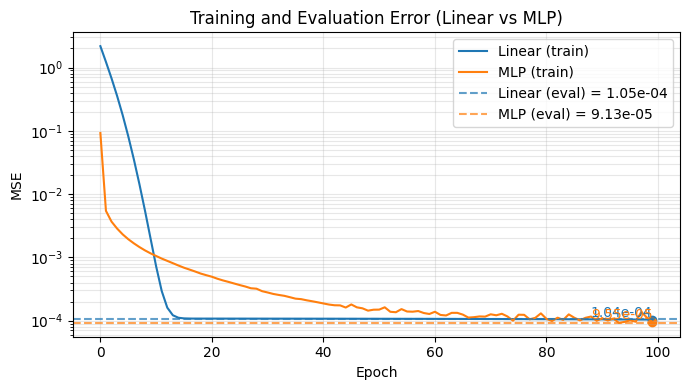

In [84]:
plt.figure(figsize=(7, 4))

# Training curves
plt.semilogy(loss_lin, label="Linear (train)", color="C0")
plt.semilogy(loss_mlp, label="MLP (train)", color="C1")

# Final training values
final_lin = loss_lin[-1]
final_mlp = loss_mlp[-1]

plt.scatter(len(loss_lin)-1, final_lin, color="C0")
plt.scatter(len(loss_mlp)-1, final_mlp, color="C1")

plt.text(
    len(loss_lin)-1, final_lin,
    f"{final_lin:.2e}",
    color="C0",
    ha="right", va="bottom"
)

plt.text(
    len(loss_mlp)-1, final_mlp,
    f"{final_mlp:.2e}",
    color="C1",
    ha="right", va="bottom"
)

# Evaluation errors (horizontal lines)
plt.axhline(
    test_loss_lin,
    color="C0",
    linestyle="--",
    alpha=0.7,
    label=f"Linear (eval) = {test_loss_lin:.2e}"
)

plt.axhline(
    test_loss_mlp,
    color="C1",
    linestyle="--",
    alpha=0.7,
    label=f"MLP (eval) = {test_loss_mlp:.2e}"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training and Evaluation Error (Linear vs MLP)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


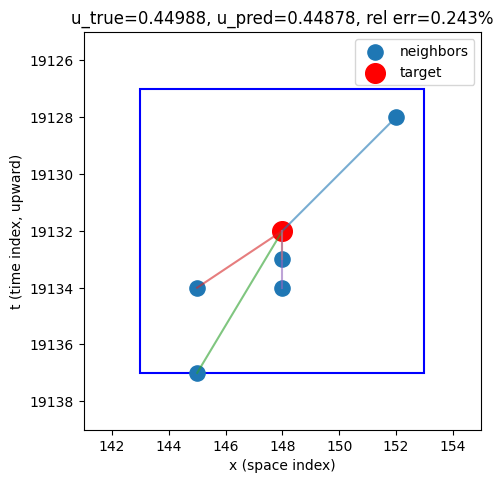

In [83]:
visualize_B_with_prediction(data, model_lin, R=R, k=k)
